In [1]:
from catboost import CatBoostClassifier, cv, Pool,metrics
import pandas as pd
from sklearn.model_selection import train_test_split
import time

In [2]:
df = pd.read_csv('../../../logs/dataframe.csv')

KeyboardInterrupt: 

In [9]:
(df['cluster'] == -1).sum() / df.shape[0]

0.287369763980438

In [3]:
model = CatBoostClassifier(
    task_type="GPU"
)

In [3]:
X, y = df.drop(columns=['cluster']), df['cluster']

In [4]:
X_train, X_validation, y_train, y_validation = train_test_split(X, y, train_size=0.75, random_state=42)

In [9]:
model.fit(
    X_train, y_train,
    eval_set=(X_validation, y_validation),
#     logging_level='Verbose',  # you can uncomment this for text output
    plot=True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Learning rate set to 0.112278
0:	learn: 2.5891794	test: 2.5853633	best: 2.5853633 (0)	total: 479ms	remaining: 7m 58s
1:	learn: 2.1770200	test: 2.1729414	best: 2.1729414 (1)	total: 938ms	remaining: 7m 48s
2:	learn: 1.9121683	test: 1.9056548	best: 1.9056548 (2)	total: 1.44s	remaining: 7m 57s
3:	learn: 1.6816086	test: 1.6755938	best: 1.6755938 (3)	total: 2s	remaining: 8m 18s
4:	learn: 1.5528680	test: 1.5505753	best: 1.5505753 (4)	total: 2.49s	remaining: 8m 15s
5:	learn: 1.4323970	test: 1.4294444	best: 1.4294444 (5)	total: 2.89s	remaining: 7m 58s
6:	learn: 1.3395284	test: 1.3389375	best: 1.3389375 (6)	total: 3.3s	remaining: 7m 47s
7:	learn: 1.2437059	test: 1.2449175	best: 1.2449175 (7)	total: 3.71s	remaining: 7m 40s
8:	learn: 1.1715264	test: 1.1727342	best: 1.1727342 (8)	total: 4.15s	remaining: 7m 37s
9:	learn: 1.1122150	test: 1.1150403	best: 1.1150403 (9)	total: 4.62s	remaining: 7m 37s
10:	learn: 1.0600876	test: 1.0682125	best: 1.0682125 (10)	total: 4.97s	remaining: 7m 26s
11:	learn: 1.02

In [4]:
import torch

In [11]:
torch.device("cuda" if torch.cuda.is_available() else "cpu")

device(type='cpu')

In [15]:
predictions = model.predict(X_validation)
predictions_probs = model.predict_proba(X_validation)
print(predictions[:10])
print(predictions_probs[:10])

[[-1]
 [31]
 [-1]
 [31]
 [28]
 [31]
 [ 1]
 [31]
 [31]
 [11]]
[[9.83633136e-01 4.19429957e-07 2.17142720e-05 1.33156319e-05
  1.06423054e-06 1.91424462e-06 1.74973941e-06 1.29712068e-04
  5.69963964e-06 5.06610227e-04 1.80179003e-06 8.72688678e-07
  1.11941352e-05 1.54267954e-05 1.22586256e-06 2.09145995e-06
  2.12519780e-06 9.33356264e-04 1.61378750e-05 1.94890637e-05
  2.89418993e-05 1.84045893e-06 2.53250861e-06 4.28996751e-05
  1.23172822e-05 3.51992814e-05 2.04613428e-03 1.21818102e-02
  1.34699892e-04 6.86932878e-07 9.53886159e-07 1.68230847e-04
  1.07350888e-05 6.81972323e-07 1.92699981e-06 1.13526017e-05]
 [2.96473317e-02 3.73253426e-07 6.70412995e-06 1.75995468e-06
  9.43165566e-07 2.54820779e-05 6.56641761e-07 5.66288071e-06
  5.76491441e-07 4.21259946e-06 1.25756575e-05 1.06983515e-07
  2.90397972e-06 1.80428525e-06 6.09194399e-07 1.05115160e-06
  9.85592228e-07 1.05221386e-06 2.07437248e-07 1.91621332e-06
  1.16245484e-06 7.62464414e-07 5.38898647e-04 6.36861047e-07
  5.2426

In [25]:
X_train

,directory_feature_0,directory_feature_1,directory_feature_2,directory_feature_3,directory_feature_4,directory_feature_5,directory_feature_6,directory_feature_7,directory_feature_8,directory_feature_9,...,user_agent.os.name_Windows,user_agent.os.name_iOS,user_agent.os.name_nan,user_agent.name_le,day,month,hour,minute,http.response.body.bytes_log2,ip_log2
5070,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,9.0,12.0,11.0,50.0,12.207014,30.556356
3133,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,9.0,12.0,9.0,11.0,13.650266,31.242705
6264,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,9.0,12.0,12.0,40.0,8.829723,26.250232
5285,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,4.0,9.0,12.0,11.0,56.0,9.859535,30.556356
3879,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,9.0,12.0,9.0,47.0,9.025140,30.556356
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,9.0,12.0,12.0,14.0,11.101319,30.556356
5191,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,9.0,12.0,11.0,53.0,11.101319,30.556356
5390,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,9.0,12.0,12.0,0.0,11.585432,30.556356
860,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,12.0,9.0,12.0,6.0,40.0,8.829723,26.292437


In [34]:
t1 = time.time()
got = X_train.sample(10)
res = model.predict(got)
t2 = time.time()
print(f"model result: {res}\nestimated: {t2-t1} seconds")

model result: [[32]
 [31]
 [ 8]
 [21]
 [-1]
 [31]
 [ 9]
 [31]
 [ 5]
 [31]]
estimated: 1.060845136642456 seconds


In [35]:
y_train.loc[got.index]

5727    32
3510    31
5166     8
1361    21
7561    -1
1109    31
768      9
2448    31
1001     5
1157    31
Name: cluster, dtype: int64

/var/folders/98/2_z7lz1x2njdn3mxm_w_h2fr0000gn/T/ipykernel_33480/2535314653.py:127: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([df["catboost_batch_s"], df["logreg_batch_s"]], labels=["CatBoost", "LogReg"])
/var/folders/98/2_z7lz1x2njdn3mxm_w_h2fr0000gn/T/ipykernel_33480/2535314653.py:131: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df["catboost_req_s"], df["logreg_req_s"]], labels=["CatBoost", "LogReg"])


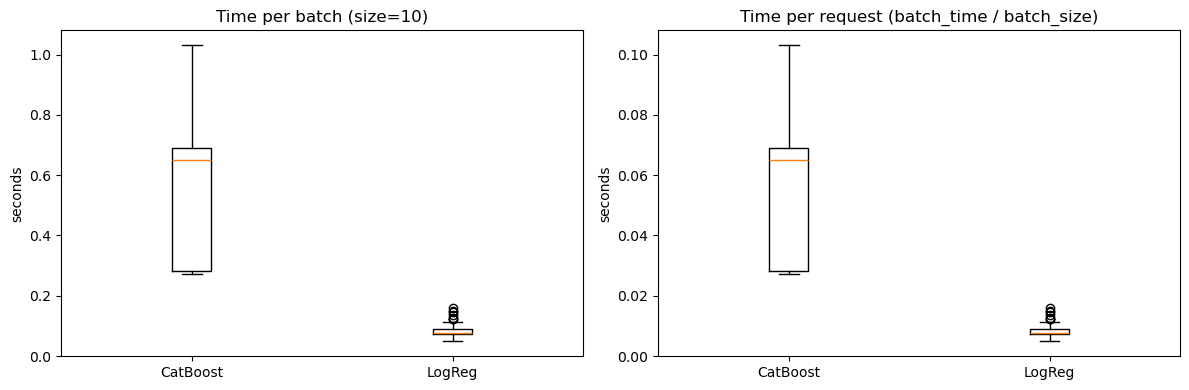

/var/folders/98/2_z7lz1x2njdn3mxm_w_h2fr0000gn/T/ipykernel_33480/2535314653.py:142: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([cat_scores, lr_scores], labels=["CatBoost", "LogReg"])


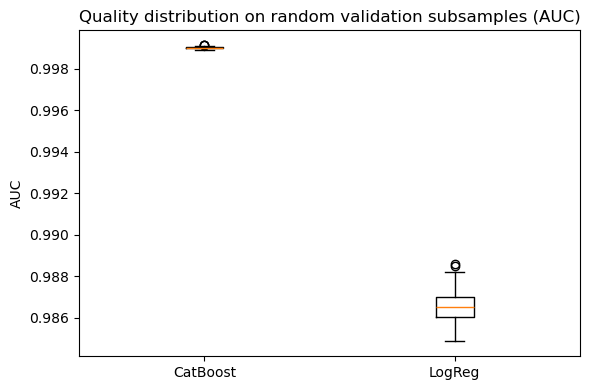

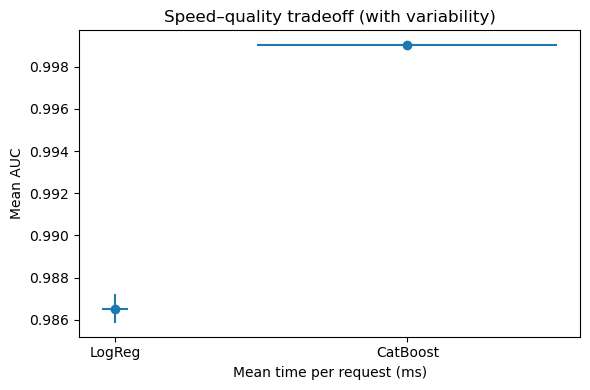

In [41]:
import numpy as np
import pandas as pd
from time import perf_counter
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score
import joblib

from sklearn.metrics import roc_auc_score, log_loss, accuracy_score

def slice_rows(X, sel):
    if hasattr(X, "iloc"):
        return X.iloc[sel]
    return X[sel]

def slice_y(y, sel):
    if hasattr(y, "iloc"):
        return y.iloc[sel].to_numpy()
    return np.asarray(y)[sel]

def evaluate_quality_distribution(
    model, X_val, y_val,
    metric="auc",
    n_repeats=200,
    sample_size=2000,
    seed=0,
    auc_multi_class="ovr",      # 'ovr' or 'ovo'
    auc_average="macro"        # 'macro' or 'weighted'
):
    rng = np.random.default_rng(seed)
    n = len(y_val)
    scores = []

    for _ in range(n_repeats):
        sel = rng.choice(n, size=min(sample_size, n), replace=False)
        Xs = slice_rows(X_val, sel)
        ys = slice_y(y_val, sel)

        proba = predict_proba_like(model, Xs)

        if metric == "auc":
            # binary: proba can be (n,2) or (n,)
            if proba.ndim == 1:
                scores.append(roc_auc_score(ys, proba))
            elif proba.shape[1] == 2:
                scores.append(roc_auc_score(ys, proba[:, 1]))
            else:
                scores.append(
                    roc_auc_score(
                        ys, proba,
                        multi_class=auc_multi_class,
                        average=auc_average
                    )
                )
        elif metric == "logloss":
            # log_loss supports multiclass if proba is (n, k)
            scores.append(log_loss(ys, proba))
        elif metric == "acc":
            # predict class from proba
            if proba.ndim == 1:
                preds = (proba >= 0.5).astype(int)
            else:
                preds = np.argmax(proba, axis=1)
            scores.append(accuracy_score(ys, preds))
        else:
            raise ValueError("metric must be one of: auc, logloss, acc")

    return np.array(scores)


def iter_batches(X, batch_size=10, rng=None):
    n = len(X)
    idx = np.arange(n)
    if rng is not None:
        rng.shuffle(idx)
    for start in range(0, n - batch_size + 1, batch_size):
        yield idx[start:start+batch_size]

def predict_proba_like(model, X_batch):
    # sklearn
    if hasattr(model, "predict_proba"):
        return np.asarray(model.predict_proba(X_batch))

    # CatBoost
    proba = model.predict(X_batch, prediction_type="Probability")
    return np.asarray(proba)


def measure_latency(model, X_val, n_batches=200, batch_size=10, warmup_batches=20, seed=0):
    rng = np.random.default_rng(seed)
    n = len(X_val)

    # Warmup
    for _ in range(warmup_batches):
        sel = rng.integers(0, n, size=batch_size)
        _ = predict_proba_like(model, slice_rows(X_val, sel))

    # Timed
    batch_times = np.empty(n_batches, dtype=float)
    for i in range(n_batches):
        sel = rng.integers(0, n, size=batch_size)
        Xb = slice_rows(X_val, sel)
        t0 = perf_counter()
        _ = predict_proba_like(model, Xb)
        batch_times[i] = perf_counter() - t0

    return batch_times, batch_times / batch_size



def slice_y(y, sel):
    # pandas Series
    if hasattr(y, "iloc"):
        return y.iloc[sel].to_numpy()
    # numpy array / list
    return np.asarray(y)[sel]

def plot_latency(cat_batch, cat_req, lr_batch, lr_req, batch_size=10):
    df = pd.DataFrame({
        "catboost_batch_s": cat_batch,
        "logreg_batch_s": lr_batch,
        "catboost_req_s": cat_req,
        "logreg_req_s": lr_req,
    })

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].boxplot([df["catboost_batch_s"], df["logreg_batch_s"]], labels=["CatBoost", "LogReg"])
    axes[0].set_title(f"Time per batch (size={batch_size})")
    axes[0].set_ylabel("seconds")

    axes[1].boxplot([df["catboost_req_s"], df["logreg_req_s"]], labels=["CatBoost", "LogReg"])
    axes[1].set_title("Time per request (batch_time / batch_size)")
    axes[1].set_ylabel("seconds")

    plt.tight_layout()
    plt.show()

    return df

def plot_quality(cat_scores, lr_scores, metric_name="AUC"):
    plt.figure(figsize=(6,4))
    plt.boxplot([cat_scores, lr_scores], labels=["CatBoost", "LogReg"])
    plt.title(f"Quality distribution on random validation subsamples ({metric_name})")
    plt.ylabel(metric_name)
    plt.tight_layout()
    plt.show()

def plot_tradeoff(cat_req_s, lr_req_s, cat_q, lr_q, metric_name="AUC"):
    x = [np.mean(cat_req_s)*1000, np.mean(lr_req_s)*1000]  # ms
    y = [np.mean(cat_q), np.mean(lr_q)]
    xerr = [np.std(cat_req_s)*1000, np.std(lr_req_s)*1000]
    yerr = [np.std(cat_q), np.std(lr_q)]

    plt.figure(figsize=(6,4))
    plt.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='o')
    plt.xticks(x, ["CatBoost", "LogReg"])
    plt.xlabel("Mean time per request (ms)")
    plt.ylabel(f"Mean {metric_name}")
    plt.title("Speed–quality tradeoff (with variability)")
    plt.tight_layout()
    plt.show()


# Assume you already have:
# cat_model, lr_model
# X_val as a NumPy array (or something sliceable), y_val as 1D array
# If X_val is a pandas DataFrame, slicing with .iloc is needed.

lr_model = joblib.load('../models/log_classifier.joblib')

batch_size = 10

cat_batch, cat_req = measure_latency(model, X_validation, n_batches=150, batch_size=batch_size, seed=1)
lr_batch,  lr_req  = measure_latency(lr_model,  X_validation, n_batches=150, batch_size=batch_size, seed=1)

lat_df = plot_latency(cat_batch, cat_req, lr_batch, lr_req, batch_size=batch_size)

cat_q = evaluate_quality_distribution(model, X_validation, y_validation,
                                     metric="auc",
                                     n_repeats=300, sample_size=2000, seed=2,
                                     auc_multi_class="ovr", auc_average="macro")

lr_q  = evaluate_quality_distribution(lr_model, X_validation, y_validation,
                                     metric="auc",
                                     n_repeats=300, sample_size=2000, seed=2,
                                     auc_multi_class="ovr", auc_average="macro")

plot_quality(cat_q, lr_q, metric_name="AUC")
plot_tradeoff(cat_req, lr_req, cat_q, lr_q, metric_name="AUC")
